# 04 - Credit Risk EDA and Portfolio Monitoring

This notebook turns the cleaned analytical dataset into a Canadian retail credit-risk monitoring view.

The purpose is to answer business questions before modelling:

- What is the observed default rate?
- Which borrower, loan, and exposure segments show elevated risk?
- Are data-quality issues concentrated in higher-risk accounts?
- Which variables are useful for portfolio monitoring but unsafe for the baseline model because of leakage or governance concerns?

This notebook is intentionally business-facing. It prepares the story that a credit-risk analyst, portfolio analyst, or model-risk reviewer would expect before model development.

## Professional framing

For a Canadian financial-institution portfolio project, EDA should not only show charts. It should create a repeatable monitoring layer.

This notebook separates three ideas:

1. **Portfolio monitoring:** understanding risk levels, exposure, missingness, and segment performance.
2. **Model-readiness review:** identifying variables that are safe to engineer later.
3. **Governance review:** documenting leakage-sensitive and proxy-sensitive fields before modelling.

Repayment variables such as `total_payment`, `received_principal`, and `interest_received` may be useful for portfolio monitoring, but they should remain excluded from the baseline early-warning model unless the prediction window is explicitly defined.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from credit_risk.config import FIGURE_DIR, PROCESSED_DIR, TABLE_DIR
from credit_risk.monitoring.portfolio_kpis import (
    portfolio_overview,
    target_distribution,
    segment_profile,
    quantile_profile,
    flag_profile,
    save_portfolio_monitoring_tables,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROCESSED_PATH = PROCESSED_DIR / "credit_risk_cleaned.csv"
PROCESSED_PATH

WindowsPath('D:/Banking and Finance/Projects/canadian-retail-credit-risk-xai/data/processed/credit_risk_cleaned.csv')

## Load cleaned dataset

In [2]:
df = pd.read_csv(PROCESSED_PATH, low_memory=False)

load_summary = {
    "row_count": df.shape[0],
    "column_count": df.shape[1],
    "record_key_duplicate_count": int(df.duplicated(["user_id", "record_sequence"]).sum()),
    "target_default_rate": float(df["defaulter"].mean()),
}
load_summary

{'row_count': 134417,
 'column_count': 46,
 'record_key_duplicate_count': 0,
 'target_default_rate': 0.0904126710163149}

The record-key duplicate count should remain zero. If this number changes, stop and return to Notebook 01 because the portfolio grain has been broken.

## Executive portfolio overview

In [3]:
overview = portfolio_overview(df)
overview.to_csv(TABLE_DIR / "portfolio_overview.csv", index=False)
overview

,metric,value
0,row_count,"134,417.0000"
1,default_count,"12,153.0000"
2,non_default_count,"122,264.0000"
3,default_rate_pct,9.0413
4,amount_missing_rate_pct,20.5614
5,total_exposure,"14,698,519,888.0000"
6,defaulted_exposure,"876,761,833.0000"
7,defaulted_exposure_share_pct,5.9650
8,median_loan_amount,"76,549.0000"
9,median_income,"62,000.0000"


In [4]:
target_dist = target_distribution(df)
target_dist.to_csv(TABLE_DIR / "portfolio_target_distribution.csv", index=False)
target_dist

,defaulter,target_label,row_count,row_pct
0,0,Non-default,122264,90.9587
1,1,Default,12153,9.0413


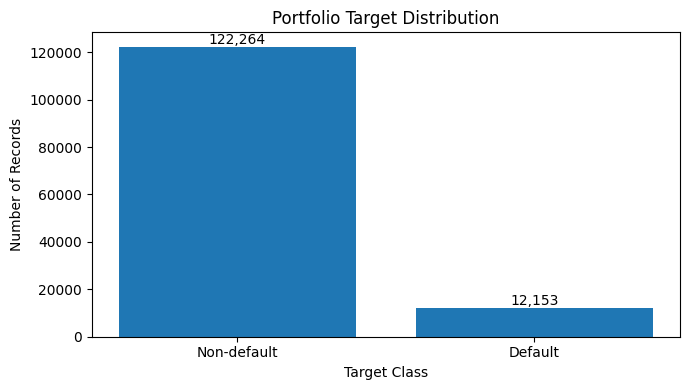

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(target_dist["target_label"], target_dist["row_count"])
ax.set_title("Portfolio Target Distribution")
ax.set_xlabel("Target Class")
ax.set_ylabel("Number of Records")
for idx, value in enumerate(target_dist["row_count"]):
    ax.text(idx, value, f"{value:,}", ha="center", va="bottom")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "portfolio_target_distribution.png", dpi=150)
plt.show()

### Interpretation

A low default rate means the modelling problem is imbalanced. Later model selection should emphasize precision, recall, PR-AUC, business cost, and threshold selection rather than accuracy alone.

## Segment risk profiles

These tables identify where default risk and exposure concentration are higher. They are not yet causal findings; they are monitoring signals for business review.

In [6]:
segment_columns = [
    "loan_category",
    "employment_type",
    "tier_of_employment",
    "work_experience",
    "home",
    "is_verified",
]

segment_tables = {}
for col in segment_columns:
    if col in df.columns:
        table = segment_profile(df, col)
        segment_tables[col] = table
        table.to_csv(TABLE_DIR / f"portfolio_segment_profile_{col}.csv", index=False)
        print()
        print(col)
        display(table.head(12))


loan_category


,loan_category,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,Business,2236,434,"70,000.0000",13.2300,19.4097,1.6635,"173,506,382.0000",43.2021,"62,201.0000",1.1804,0.8910
1,Other,8225,935,"57,900.0000",12.6400,11.3678,6.1190,"650,587,568.0000",29.4225,"46,868.0000",4.4262,0.8604
2,Medical,1379,150,"60,000.0000",12.3500,10.8774,1.0259,"130,687,686.0000",23.7854,"58,750.0000",0.8891,1.0406
3,Consolidation,80868,7637,"62,000.0000",12.0600,9.4438,60.1620,"9,009,189,646.0000",18.7565,"78,084.0000",61.2932,1.2508
4,Home,8503,735,"70,000.0000",11.7300,8.6440,6.3258,"1,104,943,930.0000",25.6968,"128,046.0000",7.5174,1.7770
5,Car,1538,115,"52,000.0000",10.8300,7.4772,1.1442,"100,351,576.0000",37.9064,"44,520.0000",0.6827,0.8736
6,Credit Card,31668,2147,"60,000.0000",10.9500,6.7797,23.5595,"3,529,253,100.0000",18.9087,"75,065.0000",24.0109,1.2371



employment_type


,employment_type,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,Self-Employed,9914,1451,"60,000.0000",12.3500,14.6359,7.3756,"661,358,688.0000",48.9510,"68,749.0000",4.4995,1.1212
1,Salaried,44817,4019,"62,000.0000",11.8400,8.9676,33.3418,"4,913,757,818.0000",20.3226,"77,357.0000",33.4303,1.2427
2,Unknown,79686,6683,"62,000.0000",11.8400,8.3867,59.2827,"9,123,403,382.0000",17.1636,"76,655.0000",62.0702,1.2416



tier_of_employment


...

,work_experience,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,2-3,1538,249,"60,000.0000",12.7300,16.1899,1.1442,"164,623,095.0000",10.9233,"55,098.0000",1.1200,0.9522
1,5-10,8132,1236,"60,000.0000",12.7300,15.1992,6.0498,"936,799,126.0000",9.7024,"67,151.0000",6.3734,1.0964
2,1-2,1843,269,"60,000.0000",12.7300,14.5958,1.3711,"217,096,596.0000",9.9837,"59,926.0000",1.4770,1.0137
3,<1,1443,203,"58,000.0000",12.7300,14.0679,1.0735,"153,151,240.0000",10.3257,"54,814.5000",1.0420,0.9709
4,10+,6486,895,"70,000.0000",12.7300,13.7990,4.8253,"954,183,466.0000",8.5415,"124,150.5000",6.4917,1.7451
5,3-5,1392,189,"60,000.0000",12.7300,13.5776,1.0356,"158,227,144.0000",11.7098,"64,613.0000",1.0765,1.0189
6,Unknown,113583,9112,"61,900.0000",11.7300,8.0223,84.5005,"12,114,439,221.0000",22.5659,"76,445.5000",82.4194,1.2383



home


,home,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,Other/None,88,16,"54,500.0000",13.8300,18.1818,0.0655,"9,352,989.0000",1.1364,"65,190.0000",0.0636,0.9992
1,Rent,56442,5853,"53,000.0000",12.0600,10.3699,41.9902,"2,111,629,876.0000",23.4896,"32,072.0000",14.3663,0.5842
2,Own,12397,1080,"53,467.0000",11.8400,8.7118,9.2228,"1,031,294,798.0000",17.5042,"39,924.0000",7.0163,0.7793
3,Mortgage,65490,5204,"72,000.0000",11.7300,7.9463,48.7215,"11,546,242,225.0000",18.6425,"188,163.0000",78.5538,2.6327



is_verified


,is_verified,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,Source Verified,33630,3125,"62,000.0000",11.8400,9.2923,25.0192,"3,659,234,232.0000",20.2706,"75,565.0000",24.8953,1.2381
1,Unknown,33507,3057,"62,000.0000",11.8400,9.1235,24.9277,"3,734,907,051.0000",20.3778,"78,946.0000",25.4101,1.2596
2,Not Verified,33722,3024,"61,798.0000",11.8400,8.9674,25.0876,"3,654,402,811.0000",20.7639,"75,422.0000",24.8624,1.2193
3,Verified,33558,2947,"62,000.0000",11.8400,8.7818,24.9656,"3,649,975,794.0000",20.8326,"76,603.0000",24.8323,1.2184


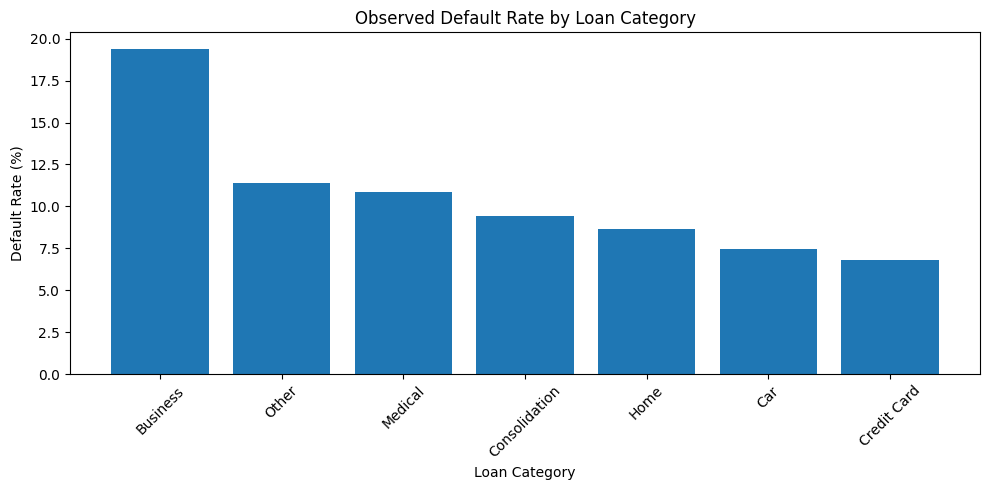

In [7]:
loan_category_profile = segment_tables["loan_category"].sort_values("default_rate_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(loan_category_profile["loan_category"].astype(str), loan_category_profile["default_rate_pct"])
ax.set_title("Observed Default Rate by Loan Category")
ax.set_xlabel("Loan Category")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "default_rate_by_loan_category.png", dpi=150)
plt.show()

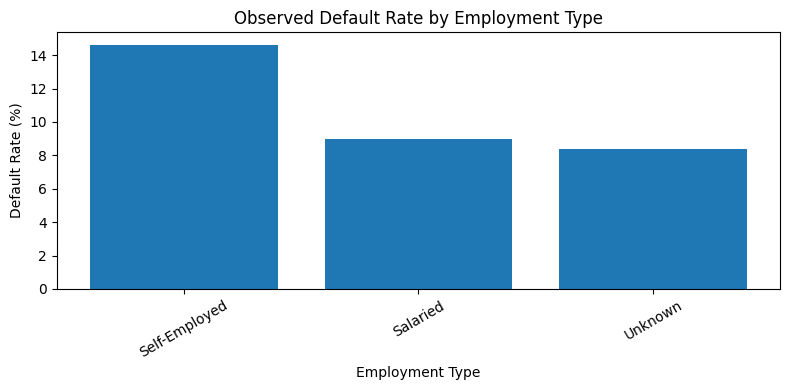

In [8]:
employment_profile = segment_tables["employment_type"].sort_values("default_rate_pct", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(employment_profile["employment_type"].astype(str), employment_profile["default_rate_pct"])
ax.set_title("Observed Default Rate by Employment Type")
ax.set_xlabel("Employment Type")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "default_rate_by_employment_type.png", dpi=150)
plt.show()

## High-risk segment shortlist

This shortlist is useful for stakeholder communication. It applies a minimum volume threshold so that very small segments do not dominate the story.

In [9]:
high_risk_segments = []
minimum_rows = 500
portfolio_default_rate = df["defaulter"].mean() * 100

for segment_name, table in segment_tables.items():
    temp = table[table["row_count"] >= minimum_rows].copy()
    temp["segment"] = segment_name
    temp["segment_value"] = temp[segment_name].astype(str)
    temp["default_rate_lift_vs_portfolio"] = temp["default_rate_pct"] / portfolio_default_rate
    high_risk_segments.append(
        temp[[
            "segment",
            "segment_value",
            "row_count",
            "portfolio_share_pct",
            "default_count",
            "default_rate_pct",
            "default_rate_lift_vs_portfolio",
            "exposure",
            "exposure_share_pct",
            "amount_missing_rate_pct",
        ]]
    )

high_risk_segments = (
    pd.concat(high_risk_segments, ignore_index=True)
    .sort_values(["default_rate_lift_vs_portfolio", "row_count"], ascending=[False, False])
    .reset_index(drop=True)
)

high_risk_segments.to_csv(TABLE_DIR / "high_risk_segment_shortlist.csv", index=False)
high_risk_segments.head(20)

,segment,segment_value,row_count,portfolio_share_pct,default_count,default_rate_pct,default_rate_lift_vs_portfolio,exposure,exposure_share_pct,amount_missing_rate_pct
0,tier_of_employment,F,1252,0.9314,305,24.3610,2.6944,"135,447,896.0000",0.9215,22.9233
1,loan_category,Business,2236,1.6635,434,19.4097,2.1468,"173,506,382.0000",1.1804,43.2021
2,tier_of_employment,E,3712,2.7616,669,18.0226,1.9934,"392,339,239.0000",2.6692,21.4170
3,work_experience,2-3,1538,1.1442,249,16.1899,1.7907,"164,623,095.0000",1.1200,10.9233
4,work_experience,5-10,8132,6.0498,1236,15.1992,1.6811,"936,799,126.0000",6.3734,9.7024
5,employment_type,Self-Employed,9914,7.3756,1451,14.6359,1.6188,"661,358,688.0000",4.4995,48.9510
6,work_experience,1-2,1843,1.3711,269,14.5958,1.6143,"217,096,596.0000",1.4770,9.9837
7,tier_of_employment,D,8163,6.0729,1163,14.2472,1.5758,"767,992,228.0000",5.2250,21.8670
8,work_experience,<1,1443,1.0735,203,14.0679,1.5560,"153,151,240.0000",1.0420,10.3257
9,work_experience,10+,6486,4.8253,895,13.7990,1.5262,"954,183,466.0000",6.4917,8.5415


## Numeric risk profiles

The following views bucket continuous variables into quantiles and compare observed default rates. This helps identify non-linear relationships before feature engineering.

In [10]:
numeric_columns = [
    "amount",
    "total_income_pa",
    "interest_rate",
    "loan_to_income_ratio",
    "delinq_2yrs",
]

numeric_profiles = {}
for col in numeric_columns:
    if col in df.columns:
        table = quantile_profile(df, col)
        numeric_profiles[col] = table
        table.to_csv(TABLE_DIR / f"portfolio_quantile_profile_{col}.csv", index=False)
        print()
        print(col)
        display(table)


amount


,bucket,row_count,default_count,min_value,max_value,median_value,default_rate_pct
0,"(4.999, 23460.6]",21356,1742,5.0000,"23,460.0000","13,912.5000",8.1570
1,"(23460.6, 48617.4]",21356,1740,"23,461.0000","48,617.0000","33,985.5000",8.1476
2,"(48617.4, 126420.8]",21355,1587,"48,619.0000","126,408.0000","76,549.0000",7.4315
3,"(126420.8, 237866.2]",21356,1513,"126,424.0000","237,863.0000","177,896.5000",7.0847
4,"(237866.2, 8000078.0]",21356,1114,"237,871.0000","8,000,078.0000","333,674.0000",5.2163



total_income_pa


,bucket,row_count,default_count,min_value,max_value,median_value,default_rate_pct
0,"(3999.999, 40000.0]",27038,3110,"4,000.0000","40,000.0000","33,000.0000",11.5023
1,"(40000.0, 55000.0]",29273,3005,"40,003.2000","55,000.0000","49,000.0000",10.2654
2,"(55000.0, 70000.0]",25302,2357,"55,000.0800","70,000.0000","63,000.0000",9.3155
3,"(70000.0, 95000.0]",26696,2096,"70,001.0000","95,000.0000","80,300.0000",7.8514
4,"(95000.0, 7141778.0]",26108,1585,"95,004.0000","7,141,778.0000","120,000.0000",6.0709



interest_rate


,bucket,row_count,default_count,min_value,max_value,median_value,default_rate_pct
0,"(5.419, 8.04]",27245,951,5.4200,8.0400,6.9500,3.4905
1,"(8.04, 10.95]",28183,1659,8.2800,10.9500,10.0600,5.8865
2,"(10.95, 12.73]",25588,2045,11.1900,12.7300,11.8400,7.9920
3,"(12.73, 15.35]",27155,2829,12.8900,15.3500,13.8300,10.4180
4,"(15.35, 23.54]",26246,4669,15.4800,23.5400,17.2100,17.7894



loan_to_income_ratio


,bucket,row_count,default_count,min_value,max_value,median_value,default_rate_pct
0,"(-0.0009444, 0.44]",21356,1518,0.0001,0.4400,0.2793,7.1081
1,"(0.44, 0.836]",21356,1861,0.4400,0.8361,0.6124,8.7142
2,"(0.836, 1.912]",21355,1516,0.8361,1.9122,1.2359,7.0990
3,"(1.912, 3.161]",21356,1380,1.9123,3.1605,2.5323,6.4619
4,"(3.161, 19.638]",21356,1421,3.1606,19.6375,4.0215,6.6539



delinq_2yrs


,bucket,row_count,default_count,min_value,max_value,median_value,default_rate_pct
0,0,110530,10177,0,0,0.0000,9.2075
1,1,16195,1375,1,1,1.0000,8.4903
2,2,4623,358,2,2,2.0000,7.7439
3,3+,3069,243,3,22,3.0000,7.9179


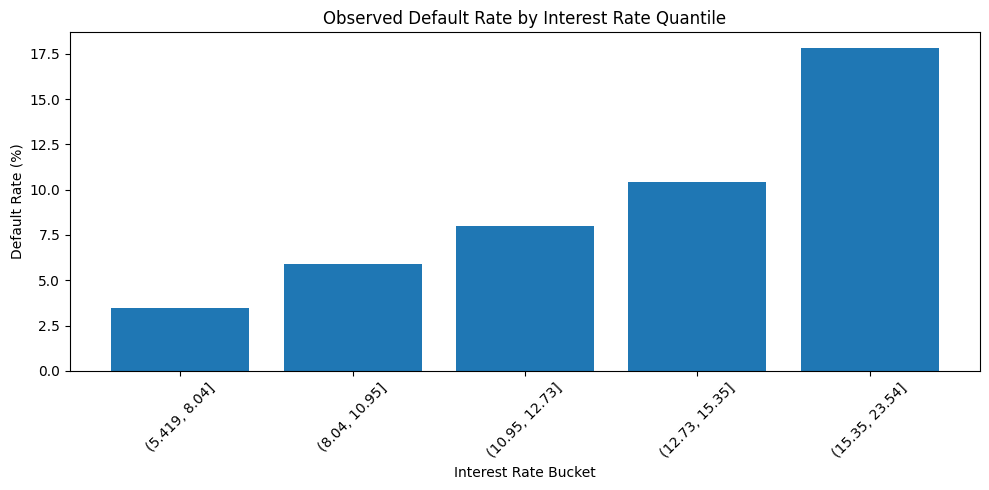

In [11]:
interest_profile = numeric_profiles["interest_rate"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(interest_profile["bucket"].astype(str), interest_profile["default_rate_pct"])
ax.set_title("Observed Default Rate by Interest Rate Quantile")
ax.set_xlabel("Interest Rate Bucket")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "default_rate_by_interest_rate_quantile.png", dpi=150)
plt.show()

## Data-quality monitoring

Data quality is a portfolio risk issue. Missing exposure information, placeholder employment values, and inconsistent repayment amounts can affect portfolio reporting and downstream model reliability.

In [12]:
flag_table = flag_profile(df)
flag_table.to_csv(TABLE_DIR / "portfolio_data_quality_flag_profile.csv", index=False)
flag_table.head(30)

,flag,flag_value,row_count,row_pct,default_count,default_rate_pct
0,amount_missing_flag,0,106779,79.4386,7696,7.2074
1,amount_missing_flag,1,27638,20.5614,4457,16.1263
2,amount_missing_raw_flag,0,106798,79.4527,7699,7.2089
3,amount_missing_raw_flag,1,27619,20.5473,4454,16.1266
4,amount_non_positive_flag,0,134398,99.9859,12150,9.0403
5,amount_non_positive_flag,1,19,0.0141,3,15.7895
6,employment_type_missing_flag,0,54731,40.7173,5470,9.9943
7,employment_type_missing_flag,1,79686,59.2827,6683,8.3867
8,has_broad_data_quality_issue,0,17890,13.3093,2657,14.8519
9,has_broad_data_quality_issue,1,116527,86.6907,9496,8.1492


In [13]:
quality_columns = [
    "amount_missing_flag",
    "employment_type_missing_flag",
    "tier_of_employment_missing_flag",
    "has_core_data_quality_issue",
    "has_broad_data_quality_issue",
]

quality_segment_tables = {}
for col in quality_columns:
    if col in df.columns:
        table = segment_profile(df, col)
        quality_segment_tables[col] = table
        print()
        print(col)
        display(table)


amount_missing_flag


,amount_missing_flag,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,1,27638,4457,"60,000.0000",11.8400,16.1263,20.5614,NaN,100.0000,NaN,NaN,NaN
1,0,106779,7696,"63,000.0000",11.8400,7.2074,79.4386,"14,698,519,888.0000",0.0000,"76,549.0000",100.0000,1.2359



employment_type_missing_flag


,employment_type_missing_flag,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,0,54731,5470,"61,200.0000",11.8400,9.9943,40.7173,"5,575,116,506.0000",25.5084,"76,319.0000",37.9298,1.2275
1,1,79686,6683,"62,000.0000",11.8400,8.3867,59.2827,"9,123,403,382.0000",17.1636,"76,655.0000",62.0702,1.2416



tier_of_employment_missing_flag


,tier_of_employment_missing_flag,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,0,54731,5470,"61,200.0000",11.8400,9.9943,40.7173,"5,575,116,506.0000",25.5084,"76,319.0000",37.9298,1.2275
1,1,79686,6683,"62,000.0000",11.8400,8.3867,59.2827,"9,123,403,382.0000",17.1636,"76,655.0000",62.0702,1.2416



has_core_data_quality_issue


,has_core_data_quality_issue,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,1,30435,4506,"58,800.0000",11.8400,14.8053,22.6422,"23,895,480.0000",90.8099,"7,294.0000",0.1626,0.1456
1,0,103982,7647,"63,000.0000",11.8400,7.3542,77.3578,"14,674,624,408.0000",0.0000,"82,025.5000",99.8374,1.3180



has_broad_data_quality_issue


,has_broad_data_quality_issue,row_count,default_count,median_income,median_interest_rate,default_rate_pct,portfolio_share_pct,exposure,amount_missing_rate_pct,median_amount,exposure_share_pct,median_loan_to_income_ratio
0,0,17890,2657,"65,000.0000",12.7300,14.8519,13.3093,"2,575,490,332.0000",0.0000,"89,763.0000",17.5221,1.4106
1,1,116527,9496,"61,000.0000",11.7300,8.1492,86.6907,"12,123,029,556.0000",23.7181,"74,291.0000",82.4779,1.2077


## Leakage-safe portfolio monitoring note

The repayment fields below may be valid for monitoring realized portfolio behaviour, collections, or repayment performance. They should not be used in the first baseline default model because they may be observed after origination or after part of the outcome period.

In [14]:
repayment_monitoring_cols = [
    "total_payment",
    "received_principal",
    "interest_received",
    "payment_to_amount_ratio",
    "principal_to_amount_ratio",
    "interest_to_amount_ratio",
]

repayment_monitoring_summary = (
    df[repayment_monitoring_cols]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)
repayment_monitoring_summary.to_csv(TABLE_DIR / "repayment_monitoring_summary.csv")
repayment_monitoring_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
total_payment,"134,417.0000","10,696.4361","8,544.3116",0.0000,912.6892,"2,012.9360","4,623.2300","8,061.1400","13,940.1600","28,575.8933","40,353.1680","57,777.5799"
received_principal,"134,417.0000","8,282.6762","7,184.0165",0.0000,504.3248,"1,325.5360","3,047.3900","5,869.1200","11,325.0000","24,000.0000","35,000.0000","35,000.0100"
interest_received,"134,417.0000","2,335.8745","2,419.9096",0.0000,97.1316,288.7100,839.5200,"1,627.0300","2,889.8800","6,994.7660","12,383.4900","24,205.6200"
payment_to_amount_ratio,"106,779.0000",0.3692,20.0826,0.0000,0.0061,0.0133,0.0381,0.0971,0.2568,0.8911,1.8760,"6,251.6800"
principal_to_amount_ratio,"106,779.0000",0.2750,10.2366,0.0000,0.0037,0.0085,0.0258,0.0693,0.1883,0.7209,1.5611,"2,819.1720"
interest_to_amount_ratio,"106,779.0000",0.0927,10.5457,0.0000,0.0007,0.0021,0.0078,0.0207,0.0573,0.1880,0.4177,"3,432.5080"


## Generate all monitoring tables from reusable code

In [15]:
generated_tables = save_portfolio_monitoring_tables(df, TABLE_DIR)

{k: v.shape for k, v in generated_tables.items()}

{'portfolio_overview': (14, 2),
 'target_distribution': (2, 4),
 'data_quality_flag_profile': (30, 6),
 'segment_profile_loan_category': (7, 12),
 'segment_profile_employment_type': (3, 12),
 'segment_profile_tier_of_employment': (8, 12),
 'segment_profile_work_experience': (7, 12),
 'segment_profile_home': (4, 12),
 'segment_profile_is_verified': (4, 12),
 'segment_profile_amount_missing_flag': (2, 12),
 'segment_profile_has_core_data_quality_issue': (2, 12),
 'quantile_profile_amount': (5, 7),
 'quantile_profile_total_income_pa': (5, 7),
 'quantile_profile_interest_rate': (5, 7),
 'quantile_profile_loan_to_income_ratio': (5, 7),
 'quantile_profile_delinq_2yrs': (4, 7)}

## Key Findings:

| Area | Result |
|---|---:|
| Portfolio rows | 134,417 |
| Default rate | 9.0413% |
| Total exposure | $14.70B |
| Defaulted exposure share | 5.97% |
| Highest-risk loan category | Business: 19.41% default rate |
| Self-employed default rate | 14.64% |
| Amount-missing default rate | 16.13% |
| Core data-quality issue default rate | 14.81% |

## The most important professional insight is this:

Missing loan amount is not just a data-quality problem. It is also a risk signal, because accounts with missing amount have a much higher observed default rate than accounts with valid amount.

So we should keep missingness flags in the modelling dataset.

## Notebook 04 conclusions

Carry these decisions forward:

1. The portfolio is imbalanced, so later modelling should not be judged by accuracy alone.
2. Segment default-rate differences should guide business interpretation but should not be treated as causal evidence.
3. `amount`, `interest_rate`, `total_income_pa`, `loan_to_income_ratio`, and delinquency history should receive careful feature-engineering review in Notebook 05.
4. Repayment-derived variables are useful for monitoring but should remain excluded from the baseline early-warning model because of leakage risk.
5. Proxy-sensitive fields such as `gender`, `married`, `pincode`, and `social_profile` should be reserved for audit/governance review rather than baseline model training.

Next notebook: **05 - Feature Engineering and Leakage Review**.